In [1]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2025-12-09 16:45:03,729 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


In [213]:
def bin_testing(visit='F21',bin_edges = None,
                print_results=False,plot=True,verbose=False):

    # Linear and Residual functions for minimization
    def linear_model(x, m, b):
        ramp = ramp_model_jax(phase=ramp_phase,r1=17.0,r2=-6.5,r3=0.0)
        return (m * x + b)*ramp
    def residual(params, x, y):
        m, b = params
        model = linear_model(x, m, b)
        return y - model # Residual = data - model

    if visit == 'F21':
        whitelight_ref_value = -0.00245
    if visit == 'S22':
        whitelight_ref_value = -0.00249
    predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
    
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    if verbose:
        print(f'N_wavelengths in visit {visit} = {rainbow.nwave}')
        print(f'N_times in visit {visit} = {rainbow.ntime}')
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    time_from_T0 = img_date - predicted_T0
    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    relative_err = rainbow.uncertainty.value/_data_flux

    'Label the orbits'
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    'Trim the first point from each orbit'
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    'Set data to nan if it was in the pre-defined list of orbits to exclude'
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    'Populate ramp_phase time arrays'
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)

    'Calculate the offset between orbits'
    if verbose:
        print('Baseline Offsets at Native Res:')
    baseline_differences = []
    for this_wave in range(data_flux.shape[0]):
        orb1 = data_flux[this_wave, orbit == 1]
        orb2 = data_flux[this_wave, orbit == 2]
        if visit =='S22':
            orb1 = data_flux[this_wave, orbit == 6]
            orb2 = data_flux[this_wave, orbit == 7]
        median_1 = np.nanmedian(orb1)
        median_2 = np.nanmedian(orb2)
        normalized_difference = (median_2-median_1)/whitelight_ref_value
        baseline_differences.append(normalized_difference)
        if verbose:
            print(f'{(normalized_difference):.5f}')
    
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
        
    'PLOT EACH LIGHT CURVE WITH THE MODEL, NEXT TO THE RESIDUALS'
    popt_list = []
    initial_guess = [-0.03, 1.0]  # m, b
    for i in range(len(data_wavelengths)):
        flux = data_flux[i, :]
        err = relative_err[i, :]
        # Fit using curve_fit
        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time_from_T0,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
            )
        # Best-fit parameters
        popt_list.append(popt)
        m_opt, b_opt = popt
        if verbose:
            print("Best-fit params:", popt)
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if print_results:
            if i == 0:
                print('Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')

    'Calculate Linear Fit and associated RMS '
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append(rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
    
    'RMS and Bin Edge Plots'
    if plot:
        fig, axes = plt.subplots(4,1,figsize=(10.0, 9),sharex=True)
        #
        axes[0].set_title(f'{visit} N_bins = {len(bin_edges)-1}')
        axes[0].set_ylabel(f'Residual RMS (ppm)')
        axes[0].plot(data_wavelengths, rms_list, color='k',lw=1)
        #
        axes[1].set_ylabel('Normalized Flux Offset')
        axes[1].plot(data_wavelengths, baseline_differences, color='k',lw=1)
        axes[1].axhline(1.0,color='k')
        #
        axes[2].set_ylabel(f'Residual RMS (ppm)')
        #
        axes[3].axhline(1.0,color='k')
        axes[3].set_ylabel('Normalized Flux Offset')
        axes[3].set_xlabel(r'Wavelength $\mu$m')
        for i in range(len(data_wavelengths)):
            axes[0].scatter(data_wavelengths[i], rms_list[i],
                            color='pink', zorder=100,alpha=0.5)
            axes[1].scatter(data_wavelengths[i], baseline_differences[i],
                            color='pink',zorder=100,alpha=0.5)
        for edge in bin_edges.value:
            axes[0].axvline(edge,color='r', linewidth=1)
            axes[1].axvline(edge,color='r', linewidth=1)
            axes[2].axvline(edge,color='r', linewidth=1)
            axes[3].axvline(edge,color='r', linewidth=1)

    ###################################################################################################
    'Now do this again but with a binnned light curve'
    rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
    rainbow = rainbow.bin(wavelength_edges=bin_edges,minimum_points_per_bin=1)
    data_wavelengths = rainbow.wavelength.value
    img_date = rainbow.time.value
    _data_flux = rainbow.flux.value
    relative_err = rainbow.uncertainty.value/_data_flux
    time_from_T0 = img_date - predicted_T0
    mean_data_flux = np.nanmean(_data_flux, axis=1)
    data_flux = _data_flux / mean_data_flux[:, np.newaxis]
    
    'Label the orbits'
    orbit = np.zeros_like(img_date)
    for j in range(len(img_date)):
        if j >= 1:
            if (img_date[j] - img_date[j - 1]) > 0.01:
                orbit[j] = (orbit[j - 1] + 1)
            else:
                orbit[j] = orbit[j - 1]
    
    'Trim the first point from each orbit'
    ref_time = []
    for o in np.unique(orbit):
        first_index = np.where(orbit == o)[0][0]
        ref_time.append(img_date[first_index])
        data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
        relative_err[:, first_index] = np.nan
        img_date[first_index] = np.nan
        time_from_T0[first_index] = np.nan
    
    'Set data to nan if it was in the pre-defined list of orbits to exclude'
    for orbit_to_exclude in np.array([0,3,4,5]):
        data_flux[:, orbit == orbit_to_exclude] = np.nan
        relative_err[:, orbit == orbit_to_exclude] = np.nan
        img_date[orbit == orbit_to_exclude] = np.nan
        time_from_T0[orbit == orbit_to_exclude] = np.nan
    
    'Populate ramp_phase time arrays'
    phase_list=[]
    for o in [0,1,2,3,4,5,6,7]:
        rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
        phase_list.append(rphase)
    ramp_phase = np.concatenate(phase_list)

    'Calculate the offset between orbits'
    if verbose:
        print('Baseline Offsets at Binned Res:')
    baseline_differences = []
    for this_wave in range(data_flux.shape[0]):
        orb1 = data_flux[this_wave, orbit == 1]
        orb2 = data_flux[this_wave, orbit == 2]
        if visit =='S22':
            orb1 = data_flux[this_wave, orbit == 6]
            orb2 = data_flux[this_wave, orbit == 7]
        median_1 = np.nanmedian(orb1)
        median_2 = np.nanmedian(orb2)
        normalized_difference = (median_2-median_1)/whitelight_ref_value
        baseline_differences.append(normalized_difference)
        if verbose:
            print(f'{(normalized_difference):.5f}')
    
    nanmask = ~np.isnan(img_date)
    data_flux = data_flux[:,nanmask]
    relative_err = relative_err[:,nanmask]
    time_from_T0 = time_from_T0[nanmask]  
    img_date = img_date[nanmask]          
    ramp_phase = ramp_phase[nanmask]
        
    'Minimize the function to find the best line'
    popt_list = []
    for i in range(len(data_wavelengths)):
        flux = data_flux[i, :]
        err = relative_err[i, :]
        popt, pcov = curve_fit(
            lambda x, m, b: linear_model(x, m, b),
            time_from_T0,
            flux,
            sigma = err,
            p0=initial_guess,
            maxfev = 100000
            )
        # Best-fit parameters
        popt_list.append(popt)
        m_opt, b_opt = popt
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
        if print_results:
            if i == 0:
                print('BINNED: Wavelength Median_rel_err linear_rms r_chisq')
            print(f'{data_wavelengths[i]:.5f} {int(np.nanmedian(relative_err[i,:])*1e6)} {rms} {rchisq:.3f}')
    
    'Calculate Linear Fit and associated RMS '
    rms_list = []
    for i in range(len(data_wavelengths)):
        m_opt, b_opt = popt_list[i]
        model_flux = linear_model(time_from_T0, m_opt, b_opt)
        residual = data_flux[i,:]-model_flux
        rms = int(np.nanstd(residual)*1e6)
        rms_list.append( rms )
        chisq = np.nansum((residual/relative_err[i,:])**2)
        rchisq = chisq/(np.sum(~np.isnan(time_from_T0))-2)
    
    if plot:
        axes[2].plot(data_wavelengths, rms_list, color='k')
        axes[3].plot(data_wavelengths, baseline_differences, color='k')
        for i in range(len(data_wavelengths)):
            axes[2].scatter(data_wavelengths[i], rms_list[i],
                            color='pink', zorder=100,alpha=0.5)
            axes[3].scatter(data_wavelengths[i], baseline_differences[i],
                            color='pink',zorder=100,alpha=0.5)
        # axes[2].set_ylim(250,1000)
        # axes[2].set_yscale('log')
        axes[3].set_ylim(0.8,1.2)
        # axes[3].set_yscale('log')

        plt.savefig(f'../../figs/{visit}_{len(bin_edges)-1}bins_bintesting_plots.png',dpi=400)
        plt.show()

    return rms_list, baseline_differences

In [214]:
'RUN THIS CELL TO GENERATE THE RMS VS BINSIZE PLOTS'
# visit = 'F21'
# fig, ax = plt.subplots(1,1,figsize=(6,3))
# for N_edges in tqdm(list(range(20, 65))):

#     n_edges = int(N_edges)
#     new_bin_edges = np.linspace(1.1313,1.641,n_edges) * u.micron
#     _rms,baseline_diffs = bin_testing(visit='F21',bin_edges = new_bin_edges,
#             print_results = False,plot=False)
#     rms = np.nanstd(_rms)
#     mean_rms = np.nanmean(_rms)
#     max_rms = np.nanmax(_rms)/rms
#     rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

#     baseline_diff_scatter = np.nanstd(baseline_diffs)

#     ax.scatter(n_edges, baseline_diff_scatter, color='k',alpha=0.3)

# ax.set_xlabel('N_edges')
# ax.set_ylabel('Std(Residual RMS)')
# ax.set_title('F21')
# plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png',dpi=200)
# plt.show()
# plt.clf()

# visit = 'S22'
# fig, ax = plt.subplots(1,1,figsize=(6,3))
# for N_edges in tqdm(list(range(20, 65))):

#     n_edges = int(N_edges)
#     new_bin_edges = np.linspace(0.7911,1.13037,n_edges) * u.micron
#     _rms,baseline_diffs = bin_testing(visit='S22',bin_edges = new_bin_edges,
#             print_results = False,plot=False)
#     rms = np.nanstd(_rms)
#     mean_rms = np.nanmean(_rms)
#     max_rms = np.nanmax(_rms)/rms
#     rms_stat = np.nanmin(_rms)/np.nanmean(_rms)

#     baseline_diff_scatter = np.nanstd(baseline_diffs)

#     ax.scatter(n_edges, baseline_diff_scatter, color='k',alpha=0.3)

# ax.set_xlabel('N_edges')
# ax.set_ylabel('Std(Residual RMS)')
# ax.set_title('S22')
# plt.savefig(f'../../figs/{visit}_rmsvsbinsize.png',dpi=200)
# plt.show()
# plt.clf()

'RUN THIS CELL TO GENERATE THE RMS VS BINSIZE PLOTS'

Wavelength Median_rel_err linear_rms r_chisq
1.13369 356 5968 287.596
1.13832 357 5162 214.170
1.14296 353 1625 21.630
1.14759 349 452 1.726
1.15222 346 1358 15.776
1.15685 346 1953 32.569
1.16149 346 3207 87.690
1.16612 342 850 6.297
1.17075 339 1692 25.556
1.17539 336 1520 20.974
1.18002 334 1364 16.995
1.18465 332 505 2.368
1.18929 330 672 4.221
1.19392 329 2634 65.766
1.19855 328 1079 11.031
1.20318 326 470 2.135
1.20782 323 422 1.749
1.21245 321 497 2.460
1.21708 320 2320 53.902
1.22172 318 2017 41.043
1.22635 316 529 2.867
1.23098 315 1221 15.365
1.23561 314 1437 21.326
1.24025 313 747 5.789
1.24488 313 1419 20.977
1.24951 313 963 9.672
1.25415 312 319 1.071
1.25878 311 427 1.925
1.26341 311 750 5.948
1.26804 311 1211 15.492
1.27268 310 1604 27.409
1.27731 309 880 8.292
1.28194 309 511 2.798
1.28658 308 1776 33.969
1.29121 305 1333 19.454
1.29584 304 3033 102.072
1.30047 305 7876 683.152
1.30511 306 8002 702.357
1.30974 303 2283 58.063
1.31437 304 3752 155.404
1.31901 301 949 10.

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

BINNED: Wavelength Median_rel_err linear_rms r_chisq
1.13713 225 333 2.249
1.14779 241 321 1.814
1.16749 134 264 3.954
1.19678 131 419 10.441
1.21952 168 305 3.380
1.24677 109 266 6.065
1.29584 84 255 9.246
1.33522 149 280 3.597
1.36766 95 278 8.689
1.40704 114 286 6.393
1.43020 174 301 3.058
1.46032 96 291 9.448
1.49761 123 331 7.343
1.52310 136 365 7.377
1.54371 151 307 4.207
1.56027 171 344 4.129
1.58112 126 394 9.902
1.60423 150 335 5.084
1.62740 128 316 6.219


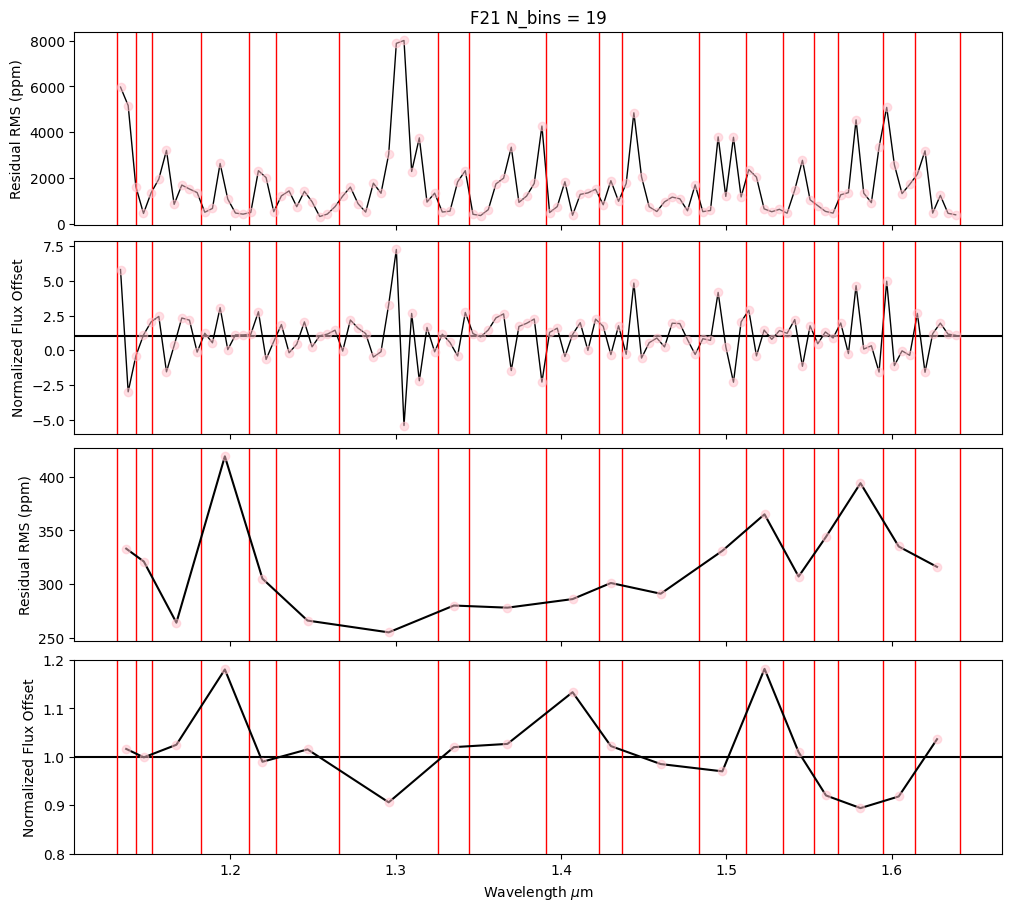

In [195]:
F21_bin_edges = np.array(
    [
        1.13130 ,
        # 1.13601	,
        # 1.14064	,
        # 1.14528	,
        1.14991	,
        # 1.15454	,
        # 1.15917	,
        1.16381	,
        # 1.16844	,
        # 1.17307	,
        # 1.17771	,
        1.18234	,
        1.18697	,
        1.19161	,
        # 1.19624	,
        # 1.20087	,
        # 1.20550	,
        # 1.21014	,
        # 1.21477	,
        # 1.21940	,
        # 1.22404	,
        # 1.22867	,
        # 1.23330	,
        1.23793	,
        # 1.24257	,
        # 1.24720	,
        # 1.25183	,
        1.25647	,
        # 1.26110	,
        # 1.26573	,
        # 1.27036	,
        # 1.27500	,
        # 1.27963	,
        # 1.28426	,
        # 1.28890	,
        # 1.29353	,
        # 1.29816	,
        # 1.30279	,
        # 1.30743	,
        # 1.31206	,
        # 1.31669	,
        # 1.32133	,
        1.32596	,
        # 1.33059	,
        # 1.33522	,
        # 1.33986	,
        1.34449	,
        # 1.34912	,
        # 1.35376	,
        # 1.35839	,
        # 1.36302	,
        # 1.36765	,
        # 1.37229	,
        # 1.37692	,
        # 1.38155	,
        # 1.38619	,
        1.39082	,
        # 1.39545	,
        # 1.40008	,
        # 1.40472	,
        # 1.40935	,
        # 1.41398	,
        # 1.41862	,
        1.42325	,
        # 1.42788	,
        # 1.43251	,
        1.43715	,
        # 1.44178	,
        # 1.44641	,
        # 1.45105	,
        # 1.45568	,
        # 1.46031	,
        # 1.46494	,
        # 1.46958	,
        # 1.47421	,
        # 1.47884	,
        1.48348	,
        # 1.48811	,
        # 1.49274	,
# 1.49737	,
# 1.50201	,
# 1.50664	,
        # 1.51127	,
# 1.51591	,
        1.52054	,
# 1.52517	,
# 1.52980	,
        1.53444	,
# 1.53907	,
# 1.54370	,
# 1.54834	,
        1.55297	,
# 1.55760	,
        # 1.56223	,
# 1.56687	,
# 1.57150	,
        # 1.57613	,
# 1.58077	,
# 1.58540	,
# 1.59003	,
        1.59466	,
# 1.59930	,
# 1.60393	,
# 1.60856	,
        # 1.61320	,
# 1.61783	,
# 1.62246	,
# 1.62709	,
        # 1.63173	,
# 1.63636	,
        1.6410
    ]
) * u.micron

F21_bin_edges = np.array(
    [1.13130 ,
1.14296,
1.15263,
1.18234	,
1.21123,
1.22782,
1.26573	,
1.32596	,
1.34449	,
1.39082	,
1.42325	,
1.43715	,
1.48348	,
1.51175,
1.53444	,
1.55297	,
1.56757,
1.59466,
1.61380,
1.641]) * u.micron

_,_ = bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,
            plot=True)

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

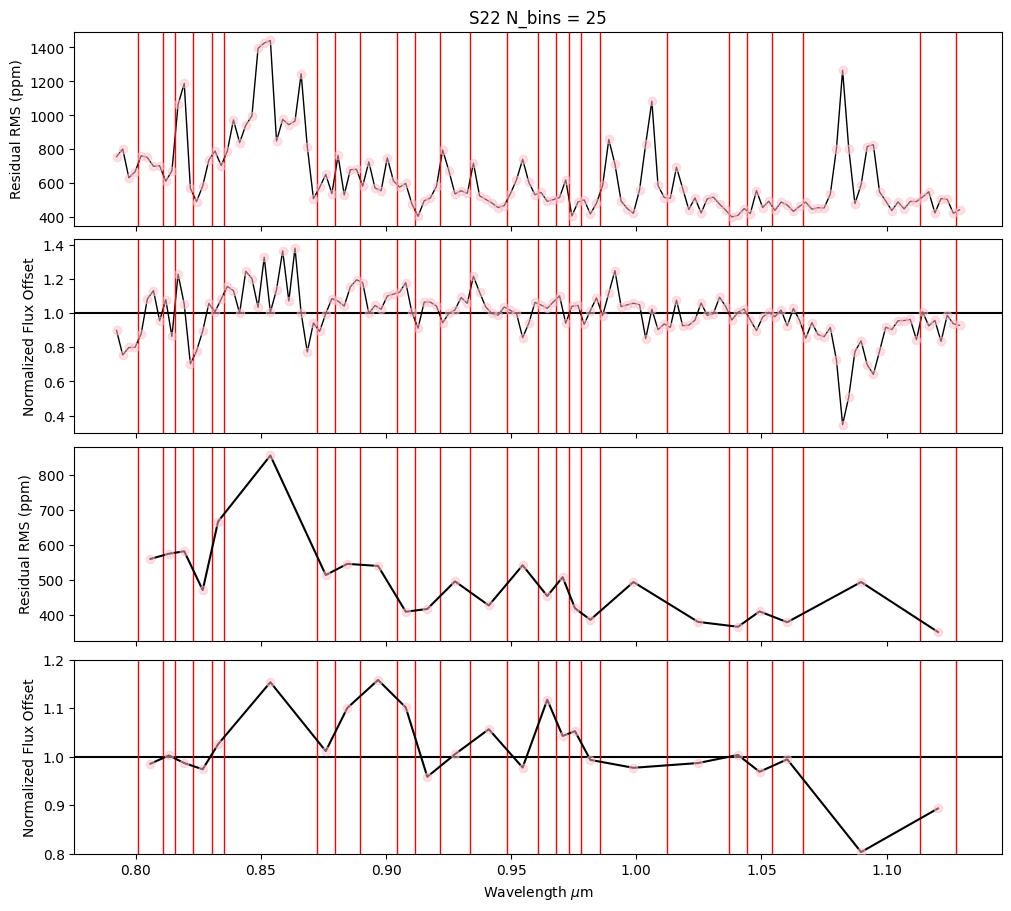

In [ ]:
S22_bin_edges = np.array(
    [
        # 0.79110,
# 0.79356,
# 0.79602,
# 0.79848,
0.80094,
# 0.80339,
# 0.80585,
# 0.80831,
0.81077,
# 0.81323,
0.81569,
# # 0.81814,
# 0.82060,
0.82306,
# 0.82552,
# 0.82798,
0.83044,
# 0.83290,
0.83535,
# 0.83781,
# 0.84027,
# 0.84273,
# 0.84519,
# 0.84765,
# 0.85010,
# 0.85256,
# 0.85502,
# 0.85748,
# 0.85994,
# 0.86240,
# 0.86485,
# 0.86731,
# 0.86977,
0.87223,
# 0.87469,
# 0.87715,
0.87961,
# 0.88206,
# 0.88452,
# 0.88698,
0.88944,
# 0.89190,
# 0.89436,
# 0.89681,
# 0.89927,
# 0.90173,
0.90419,
# 0.90665,
# 0.90911,
0.91157,
# 0.91402,
# 0.91648,
# 0.91894,
0.92140,
# 0.92386,
# 0.92632,
# 0.92877,
# 0.93123,
0.93369,
# 0.93615,
# 0.93861,
# 0.94107,
# 0.94352,
# 0.94598,
0.94844,
# 0.95090,
# 0.95336,
# 0.95582,
# 0.95828,
0.96073,
# 0.96319,
# 0.96565,
0.96811,
# 0.97057,
0.97303,
# 0.97548,
0.97794,
# 0.98040,
# 0.98286,
0.98532,
# 0.98778,
# 0.99024,
# 0.99269,
# 0.99515,
# 0.99761,
# 1.00007,
# 1.00253,
# 1.00499,
# 1.00744,
# 1.00990,
1.01236,
# 1.01482,
# 1.01728,
# 1.01974,
# 1.02220,
# 1.02465,
# 1.02711,
# 1.02957,
# 1.03203,
# 1.03449,
1.03695,
# 1.03940,
# 1.04186,
1.04432,
# 1.04678,
# 1.04924,
# 1.05170,
1.05415,
# 1.05661,
# 1.05907,
# 1.06153,
# 1.06399,
1.06645,
# 1.06891,
# 1.07136,
# 1.07382,
# 1.07628,
# 1.07874,
# 1.08120,
# 1.08366,
# 1.08611,
# 1.08857,
# 1.09103,
# 1.09349,
# 1.09595,
# 1.09841,
# 1.10087,
# 1.10332,
# 1.10578,
# 1.10824,
# 1.11070,
# 1.11316,xddddddddddddddsssdsdvadcvsdvvdsvdfdfvfdvvdfdfv
1.11562,
1.11807,
1.12053,
1.12299,
1.12545,
1.12791,
# 1.1304
]
# ) * u.micron                        


_,_ = bin_testing(visit='S22',
            bin_edges = S22_bin_edges,
            print_results = False,
            plot=True)

In [ ]:
'FOR THE TRANSMISSION LIGHT CURVES'

F21_bin_edges = np.linspace(1.14,1.64,49) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,42) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,31) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,24) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}' )
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.linspace(1.14,1.64,17) * u.micron
# for edge in F21_bin_edges:
    # print(f'{edge.value:.6f}')
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges =jnp.array([1.14064,1.16381,1.18234,1.20087,
                          1.21477,1.23793,1.25647,1.28426,
                          1.31669,1.33059,1.34449,1.35839,
                          1.39082,1.40935,1.42325,1.43715,
                          1.45568,1.47421,1.51127,1.52980,
                          1.54834,1.57150,1.62246,1.64])*u.micron
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

F21_bin_edges = np.array([1.13, 1.159170,1.210135,
                          1.25183, 1.28426,1.325955,
                          1.34912, 1.390815,1.413980, 
                          1.460305, 1.488105,1.5298,
                          1.566865,1.62245,1.64]) * u.micron
bin_testing(visit='F21',
            bin_edges = F21_bin_edges,
            print_results = True,plot=True)

In [ ]:
S22_bin_edges = np.linspace(0.79,1.13,61) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

In [ ]:
S22_bin_edges = np.linspace(0.79,1.13,61) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,53) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,41) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,31) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.linspace(0.82,1.13,22) * u.micron
# for edge in S22_bin_edges:
#     print(f'{edge.value:.6f}')
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)

S22_bin_edges = np.array([0.82, 0.82306047, 0.8304358 ,0.8697709 , 
                          0.87960467,0.88943845, 0.90418911,0.91156444, 
                          0.92139821, 0.93369043, 0.94844109, 0.96073331, 
                          0.96810864, 0.97302553, 0.97794241,0.98531775,
                          1.01481907,1.02465284, 1.03202817, 1.03694506, 
                          1.04432039, 1.05661261, 1.06644638, 1.07382171, 
                          1.10086459,1.11315681,1.12299059, 1.13]) * u.micron
bin_testing(visit='S22',bin_edges = S22_bin_edges,
        print_results = True,plot=True)